# NsDiff: Non-stationary Diffusion for Probabilistic Time Series Forecasting

**Paper**: [arXiv:2505.04278](https://arxiv.org/abs/2505.04278) — Wang et al., 2025

**Key Innovation**: Standard DDPMs assume stationary noise schedules, which is ill-suited for non-stationary time series where variance changes over time. NsDiff derives a **data-dependent forward diffusion** whose noise scales adapt to local statistics via two learned components:

| Component | Role | Architecture |
|-----------|------|-------------|
| **f(x)** | Mean predictor — provides prior mean y\_T\_mean and denoising target y\_0\_hat | Non-Stationary Transformer (DSAttention + tau/delta Projectors) |
| **g(x)** | Variance predictor — estimates future variance from rolling window statistics | MLP on trailing-window variance features |
| **ε_θ** | Conditional denoiser — predicts noise ε and variance σ from (y_t, y\_0\_hat, g\_x, t) | ConditionalLinear layers with timestep-specific scaling |

**Non-stationary forward process**: q(y_t | y_0, x) = N(√ā_t · y_0 + (1−√ā_t) · f(x), noise_var)
where noise_var = (β̄_t − β̃_t) · g(x) + β̃_t · Σ_{Y_0}  (data-dependent!)

**3-stage training**: (1) Pretrain f(x) with MSE, (2) Pretrain g(x) with variance MSE, (3) Train denoiser with frozen f(x), g(x)

This notebook is self-contained, uses random tensor time series, and runs on Google Colab.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from copy import deepcopy

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

Key hyperparameters following the paper: K=20 diffusion steps, linear β schedule [1e-4, 0.01], d_model=128, 4 attention heads, 2 encoder / 1 decoder layers, rolling variance window of 24 steps.

In [2]:
class Config:
    # Data dimensions
    seq_len = 96          # input (lookback) length
    pred_len = 24         # prediction horizon
    label_len = 48        # decoder context overlap with encoder
    enc_in = 7            # number of input variables
    c_out = 7             # number of output variables

    # Non-Stationary Transformer (f(x) mean predictor)
    d_model = 128
    n_heads = 4
    d_ff = 256
    e_layers = 2          # encoder layers
    d_layers = 1          # decoder layers
    dropout = 0.1
    activation = 'gelu'
    p_hidden_dims = [128, 128]  # Projector hidden dimensions
    p_hidden_layers = 2         # Projector hidden layers

    # Variance predictor g(x)
    kernel_size = 24      # rolling window for variance computation
    g_hidden = 128

    # Non-stationary diffusion
    timesteps = 20        # K diffusion steps
    beta_start = 1e-4
    beta_end = 0.01
    beta_schedule = 'linear'

    # Training
    batch_size = 32
    lr_f = 1e-3           # f(x) learning rate
    lr_g = 1e-3           # g(x) learning rate
    lr_diff = 1e-4        # denoiser learning rate
    epochs_f = 30         # Stage 1 epochs
    epochs_g = 20         # Stage 2 epochs
    epochs_diff = 40      # Stage 3 epochs

    # Inference
    n_samples = 20        # diffusion samples for uncertainty quantification

    # Data generation
    n_train = 800
    n_val = 100
    n_test = 100

config = Config()
print(f'Input: ({config.seq_len}, {config.enc_in}) -> Target: ({config.pred_len}, {config.c_out})')
print(f'Diffusion: K={config.timesteps}, beta=[{config.beta_start}, {config.beta_end}]')
print(f'3-stage training: {config.epochs_f} + {config.epochs_g} + {config.epochs_diff} epochs')

Input: (96, 7) -> Target: (24, 7)
Diffusion: K=20, beta=[0.0001, 0.01]
3-stage training: 30 + 20 + 40 epochs


## Random Non-Stationary Time Series Dataset

Generates multivariate time series with time-varying amplitude (non-stationarity), multiple frequencies, trends, and heteroscedastic noise — mimicking real-world patterns where NsDiff's non-stationary diffusion excels.

In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, n_samples, seq_len, pred_len, n_features, label_len):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.label_len = label_len
        total_len = seq_len + pred_len
        t = torch.linspace(0, 4 * math.pi, total_len)
        self.data = []
        for _ in range(n_samples):
            features = []
            for f_idx in range(n_features):
                freq = 0.5 + torch.rand(1).item() * 2
                phase = torch.rand(1).item() * 2 * math.pi
                amp = 0.5 + torch.rand(1).item()
                trend = (torch.rand(1).item() - 0.5) * 0.02
                amp_mod = 1 + 0.3 * torch.sin(t * 0.5 + torch.rand(1).item() * math.pi)
                signal = amp * amp_mod * torch.sin(freq * t + phase) + trend * t
                noise_scale = 0.1 + 0.1 * torch.abs(torch.sin(t * 0.3))
                signal = signal + noise_scale * torch.randn(total_len)
                features.append(signal)
            self.data.append(torch.stack(features, dim=-1))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        series = self.data[idx]
        x_enc = series[:self.seq_len]                           # (seq_len, N)
        y = series[self.seq_len:]                               # (pred_len, N)
        x_dec = torch.cat([                                     # (label_len + pred_len, N)
            series[self.seq_len - self.label_len:self.seq_len],
            torch.zeros(self.pred_len, series.shape[-1])
        ], dim=0)
        return x_enc, x_dec, y


train_ds = TimeSeriesDataset(config.n_train, config.seq_len, config.pred_len, config.enc_in, config.label_len)
val_ds = TimeSeriesDataset(config.n_val, config.seq_len, config.pred_len, config.enc_in, config.label_len)
test_ds = TimeSeriesDataset(config.n_test, config.seq_len, config.pred_len, config.enc_in, config.label_len)

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False)

x_enc, x_dec, y = next(iter(train_loader))
print(f'x_enc: {x_enc.shape}  x_dec: {x_dec.shape}  y: {y.shape}')

x_enc: torch.Size([32, 96, 7])  x_dec: torch.Size([32, 72, 7])  y: torch.Size([32, 24, 7])


## Data Embedding

Projects raw features to d_model dimensions and adds sinusoidal positional encoding. Used by both encoder and decoder branches of the Non-Stationary Transformer.

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.position_encoding = PositionalEncoding(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.position_encoding(self.value_embedding(x)))


# Quick shape test
_emb = DataEmbedding(config.enc_in, config.d_model)
print(f'Embedding: {x_enc.shape} -> {_emb(x_enc).shape}')
del _emb

Embedding: torch.Size([32, 96, 7]) -> torch.Size([32, 96, 128])


## De-Stationary Attention (DSAttention)

From the **Non-Stationary Transformer** (NeurIPS 2022). Standard attention on instance-normalized input loses distribution information. DSAttention restores it with two learned factors:

- **τ (tau)**: Rescales attention scores to compensate for variance change after normalization. Learned from raw input + std.
- **Δ (delta)**: Position-dependent additive bias that restores trend information. Learned from raw input + mean.

$$\text{DSAttn}(Q, K, V, \tau, \Delta) = \text{Softmax}\left(\tau \cdot \frac{QK^T}{\sqrt{d_k}} + \Delta\right) V$$

In [5]:
class DSAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, tau=None, delta=None, attn_mask=None):
        B, L, _ = queries.shape
        S = keys.shape[1]
        H = self.n_heads

        Q = self.W_Q(queries).view(B, L, H, self.d_k).permute(0, 2, 1, 3)  # B, H, L, d_k
        K = self.W_K(keys).view(B, S, H, self.d_k).permute(0, 2, 1, 3)     # B, H, S, d_k
        V = self.W_V(values).view(B, S, H, self.d_k).permute(0, 2, 1, 3)   # B, H, S, d_k

        scale = 1.0 / math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * scale  # B, H, L, S

        # De-stationary rescaling and shifting
        if tau is not None:
            scores = scores * tau.unsqueeze(1).unsqueeze(1)   # tau: B x 1 -> B x 1 x 1 x 1
        if delta is not None:
            scores = scores + delta.unsqueeze(1).unsqueeze(2) # delta: B x S -> B x 1 x 1 x S

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)  # B, H, L, d_k
        out = out.permute(0, 2, 1, 3).contiguous().view(B, L, -1)  # B, L, d_model
        return self.W_O(out)

## Transformer Components: Projector, Encoder, Decoder

**Projector**: Learns de-stationary factors τ and Δ. Compresses the raw input via Conv1d (treating time steps as channels), concatenates with statistics (mean or std), and maps through an MLP.

**EncoderLayer**: DSAttention self-attention + feed-forward with LayerNorm residuals.

**DecoderLayer**: DSAttention self-attention (without delta) + cross-attention (with delta) + feed-forward.

In [6]:
class Projector(nn.Module):
    """Learns de-stationary factors (tau or delta) from raw input + statistics."""
    def __init__(self, enc_in, seq_len, hidden_dims, hidden_layers, output_dim, kernel_size=3):
        super().__init__()
        padding = 1 if kernel_size == 3 else kernel_size // 2
        self.series_conv = nn.Conv1d(
            in_channels=seq_len, out_channels=1,
            kernel_size=kernel_size, padding=padding,
            padding_mode='circular', bias=False
        )
        layers = [nn.Linear(2 * enc_in, hidden_dims[0]), nn.ReLU()]
        for i in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dims[i], hidden_dims[i + 1]), nn.ReLU()]
        layers += [nn.Linear(hidden_dims[-1], output_dim, bias=False)]
        self.backbone = nn.Sequential(*layers)

    def forward(self, x, stats):
        # x: (B, seq_len, enc_in) — raw input
        # stats: (B, 1, enc_in) — mean or std of input
        B = x.shape[0]
        x = self.series_conv(x)           # (B, 1, enc_in)
        x = torch.cat([x, stats], dim=1)  # (B, 2, enc_in)
        x = x.view(B, -1)                 # (B, 2*enc_in)
        return self.backbone(x)            # (B, output_dim)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, activation='gelu'):
        super().__init__()
        self.attention = DSAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), act, nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, tau=None, delta=None):
        attn_out = self.attention(x, x, x, tau=tau, delta=delta)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, activation='gelu'):
        super().__init__()
        self.self_attention = DSAttention(d_model, n_heads, dropout)
        self.cross_attention = DSAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), act, nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, cross, tau=None, delta=None):
        # Self-attention: no delta (decoder positions don't need key-shifting)
        sa_out = self.self_attention(x, x, x, tau=tau, delta=None)
        x = self.norm1(x + self.dropout(sa_out))
        # Cross-attention: delta shifts encoder keys
        ca_out = self.cross_attention(x, cross, cross, tau=tau, delta=delta)
        x = self.norm2(x + self.dropout(ca_out))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

## f(x): Mean Predictor — Non-Stationary Transformer

Predicts the deterministic mean forecast ŷ₀ = f(x), which serves as:
1. The **prior mean** at timestep T: y_T ~ N(f(x), g(x))
2. The **conditioning signal** for the denoiser: ε_θ(y_t, ŷ₀, g(x), t)

Architecture: Instance normalization → DSAttention Encoder → DSAttention Decoder → De-normalization. The Projector modules learn τ (from raw input + std) and Δ (from raw input + mean) to restore distribution information lost during normalization.

In [7]:
class MeanPredictor(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.pred_len = config.pred_len
        self.seq_len = config.seq_len
        self.label_len = config.label_len

        self.enc_embedding = DataEmbedding(config.enc_in, config.d_model, config.dropout)
        self.dec_embedding = DataEmbedding(config.enc_in, config.d_model, config.dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config.d_model, config.n_heads, config.d_ff, config.dropout, config.activation)
            for _ in range(config.e_layers)
        ])
        self.encoder_norm = nn.LayerNorm(config.d_model)

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(config.d_model, config.n_heads, config.d_ff, config.dropout, config.activation)
            for _ in range(config.d_layers)
        ])
        self.decoder_norm = nn.LayerNorm(config.d_model)
        self.projection = nn.Linear(config.d_model, config.c_out)

        self.tau_learner = Projector(config.enc_in, config.seq_len, config.p_hidden_dims,
                                     config.p_hidden_layers, output_dim=1)
        self.delta_learner = Projector(config.enc_in, config.seq_len, config.p_hidden_dims,
                                       config.p_hidden_layers, output_dim=config.seq_len)

    def forward(self, x_enc, x_dec):
        # Instance normalization
        x_raw = x_enc.clone().detach()
        mean_enc = x_enc.mean(1, keepdim=True).detach()       # B x 1 x N
        x_enc_norm = x_enc - mean_enc
        std_enc = torch.sqrt(torch.var(x_enc_norm, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
        x_enc_norm = x_enc_norm / std_enc

        # Decoder input: normalized encoder tail + zero-padded prediction slots
        x_dec_new = torch.cat([
            x_enc_norm[:, -self.label_len:, :],
            torch.zeros_like(x_dec[:, -self.pred_len:, :])
        ], dim=1)

        # Learn de-stationary factors from raw input
        tau = self.tau_learner(x_raw, std_enc).exp()    # B x 1 (positive)
        delta = self.delta_learner(x_raw, mean_enc)     # B x seq_len

        # Encode
        enc_out = self.enc_embedding(x_enc_norm)
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, tau=tau, delta=delta)
        enc_out = self.encoder_norm(enc_out)

        # Decode
        dec_out = self.dec_embedding(x_dec_new)
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, tau=tau, delta=delta)
        dec_out = self.decoder_norm(dec_out)
        dec_out = self.projection(dec_out)

        # De-normalization
        dec_out = dec_out * std_enc + mean_enc
        return dec_out[:, -self.pred_len:, :]


# Shape test
_f = MeanPredictor(config)
print(f'f(x): ({x_enc.shape}, {x_dec.shape}) -> {_f(x_enc, x_dec).shape}')
del _f

f(x): (torch.Size([32, 96, 7]), torch.Size([32, 72, 7])) -> torch.Size([32, 24, 7])


## g(x): Variance Predictor

Estimates the future variance g(x) = σ²_pred from the input series. Uses:
1. **Trailing-window variance**: Computes local variance over a sliding window of size `kernel_size` along the input
2. **MLP projection**: Maps the windowed variance features to the prediction horizon
3. **Softplus output**: Ensures predicted variance is always positive

g(x) enters the diffusion process as the data-dependent noise scale in both forward and reverse directions.

In [8]:
class VariancePredictor(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in, hidden_size=128, kernel_size=24):
        super().__init__()
        self.pred_len = pred_len
        self.kernel_size = kernel_size
        mlp_input_size = seq_len - kernel_size  # trailing window discards first kernel_size positions
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, pred_len)
        )

    def forward(self, x_enc):
        B, T, N = x_enc.shape
        # Trailing-window variance (no padding — discard first kernel_size positions)
        windows = x_enc.unfold(1, self.kernel_size, 1)  # B, T-k+1, N, k
        sigma = windows.var(dim=3, unbiased=False)       # B, T-k+1, N
        sigma = sigma[:, -(T - self.kernel_size):, :] + 1e-7  # B, T-k, N
        # MLP: map temporal variance features to prediction horizon
        pred_sigma = self.mlp(sigma.permute(0, 2, 1))    # B, N, pred_len
        pred_sigma = F.softplus(pred_sigma).permute(0, 2, 1)  # B, pred_len, N
        return pred_sigma[:, -self.pred_len:, :]


# Shape test
_g = VariancePredictor(config.seq_len, config.pred_len, config.enc_in, config.g_hidden, config.kernel_size)
_g_out = _g(x_enc)
print(f'g(x): {x_enc.shape} -> {_g_out.shape}, all positive: {(_g_out > 0).all().item()}')
del _g, _g_out

g(x): torch.Size([32, 96, 7]) -> torch.Size([32, 24, 7]), all positive: True


## Conditional Denoiser ε_θ

The denoiser predicts noise ε and variance σ from the noisy target y_t, conditioned on the mean prediction ŷ₀ and variance g(x).

**ConditionalLinear**: Each linear layer has a learned timestep-specific scaling factor γ_t via an embedding table. This allows the network to adapt its behavior at each diffusion step: γ_t · Linear(x).

**ConditionalGuidedModel**: 3 ConditionalLinear layers with softplus activations, followed by two output heads:
- `lin4`: Predicts noise ε_θ (unconstrained)
- `sigma_lin`: Predicts variance σ_θ (softplus-constrained, always positive)

In [9]:
class ConditionalLinear(nn.Module):
    def __init__(self, num_in, num_out, n_steps):
        super().__init__()
        self.num_out = num_out
        self.lin = nn.Linear(num_in, num_out)
        self.embed = nn.Embedding(n_steps, num_out)
        nn.init.uniform_(self.embed.weight)

    def forward(self, x, t):
        out = self.lin(x)                                    # B, pred_len, num_out
        gamma = self.embed(t).view(t.shape[0], 1, self.num_out)  # B, 1, num_out
        return gamma * out                                   # timestep-specific scaling


class ConditionalGuidedModel(nn.Module):
    def __init__(self, diff_steps, enc_in):
        super().__init__()
        n_steps = diff_steps + 1
        data_dim = enc_in * 3  # concat(y_t, y_0_hat, g_x)
        self.lin1 = ConditionalLinear(data_dim, 128, n_steps)
        self.lin2 = ConditionalLinear(128, 128, n_steps)
        self.lin3 = ConditionalLinear(128, 128, n_steps)
        self.lin4 = nn.Linear(128, enc_in)       # noise prediction head
        self.sigma_lin = nn.Linear(128, enc_in)   # variance prediction head

    def forward(self, y_t, y_0_hat, g_x, t):
        x = torch.cat((y_t, y_0_hat, g_x), dim=-1)  # B, pred_len, 3*enc_in
        x = F.softplus(self.lin1(x, t))
        x = F.softplus(self.lin2(x, t))
        x = F.softplus(self.lin3(x, t))
        eps_pred = self.lin4(x)                       # B, pred_len, enc_in
        sigma = F.softplus(self.sigma_lin(F.softplus(x)))  # B, pred_len, enc_in (positive)
        return eps_pred, sigma


# Shape test
_den = ConditionalGuidedModel(config.timesteps, config.enc_in)
_yt = torch.randn(4, config.pred_len, config.enc_in)
_t = torch.randint(0, config.timesteps, (4,))
_eps, _sig = _den(_yt, _yt, _yt, _t)
print(f'Denoiser: concat({_yt.shape}, ..., ...) -> eps {_eps.shape}, sigma {_sig.shape}')
del _den, _yt, _t, _eps, _sig

Denoiser: concat(torch.Size([4, 24, 7]), ..., ...) -> eps torch.Size([4, 24, 7]), sigma torch.Size([4, 24, 7])


## Non-Stationary Diffusion Schedule

NsDiff extends the standard DDPM schedule with data-dependent terms:

| Term | Definition | Role |
|------|-----------|------|
| ā_t = ∏ᵢ αᵢ | Standard cumulative product | Controls signal retention |
| α̃_t = Σ_{i=0}^{t} ∏_{j=i}^{t} α_j | Cumulative sum of partial products | Non-stationary mean accumulation |
| α̂_t = Σ_{i=0}^{t} (∏_{j=i}^{t} α_j) · α_i | Squared partial products | Non-stationary variance accumulation |
| β̃_t = α̃_t − α̂_t | Tilde-beta | Modulates data-dependent noise |
| β̄_t = 1 − ā_t | Bar-beta (standard) | Total noise at step t |

The forward noise variance becomes: (β̄_t − β̃_t)·g(x) + β̃_t·Σ_{Y_0}

In [10]:
def make_beta_schedule(schedule, num_timesteps, start, end):
    if schedule == 'linear':
        return torch.linspace(start, end, num_timesteps)
    elif schedule == 'quad':
        return torch.linspace(start**0.5, end**0.5, num_timesteps)**2
    elif schedule == 'cosine':
        s = 0.008
        return torch.tensor([
            min(1 - (math.cos(((i+1)/num_timesteps + s)/(1+s) * math.pi/2)**2) /
                (math.cos((i/num_timesteps + s)/(1+s) * math.pi/2)**2), 0.999)
            for i in range(num_timesteps)])
    return torch.linspace(start, end, num_timesteps)


def compute_tilde_alpha(alpha):
    """alpha_tilde_t = sum_{i=0}^{t} prod_{j=i}^{t} alpha_j"""
    alpha = alpha.float()
    n = alpha.shape[0]
    tilde = torch.zeros_like(alpha)
    for t in range(n):
        sl = alpha[:t+1].flip(0)
        tilde[t] = torch.cumprod(sl, dim=0).sum()
    return tilde


def compute_hat_alpha(alpha):
    """alpha_hat_t = sum_{i=0}^{t} (prod_{j=i}^{t} alpha_j) * alpha_i"""
    alpha = alpha.float()
    n = alpha.shape[0]
    hat = torch.zeros_like(alpha)
    for t in range(n):
        sl = alpha[:t+1].flip(0)
        cp = torch.cumprod(sl, dim=0)
        hat[t] = (cp * sl).sum()
    return hat


def extract(input_tensor, t, x):
    """Extract values from 1D tensor at indices t, reshape for broadcasting."""
    out = torch.gather(input_tensor, 0, t.to(input_tensor.device))
    return out.reshape([t.shape[0]] + [1] * (len(x.shape) - 1))


# Verify schedule properties
_betas = make_beta_schedule('linear', 20, 1e-4, 0.01)
_alphas = 1 - _betas
_tilde = compute_tilde_alpha(_alphas)
_hat = compute_hat_alpha(_alphas)
_btilde = _tilde - _hat
_bbar = 1 - torch.cumprod(_alphas, 0)
print(f'beta_tilde >= 0: {(_btilde >= 0).all().item()}')
print(f'beta_bar >= beta_tilde: {((_bbar - _btilde) >= 0).all().item()}')
del _betas, _alphas, _tilde, _hat, _btilde, _bbar

beta_tilde >= 0: True
beta_bar >= beta_tilde: True


## NsDiff: Full Model

Combines f(x), g(x), and the denoiser into the complete non-stationary diffusion model.

**Forward diffusion** (training): y_t = √ā_t · y_0 + (1−√ā_t) · ŷ₀ + ε, where ε ~ N(0, I)

**Reverse diffusion** (inference): Starting from y_T ~ N(f(x), g(x)), iteratively denoise using:
1. Estimate Σ_{Y_0} via quadratic formula from denoiser-predicted σ_θ
2. Compute data-dependent noise variance
3. Reparameterize y_0 from ε_θ prediction
4. Compute posterior mean using γ_0, γ_1, γ_2 coefficients
5. Add stochastic noise scaled by σ_θ

**3-stage training loss**:
- Stage `f`: MSE(f(x), y_0) — mean prediction
- Stage `g`: MSE(g(x), target_variance) — variance prediction
- Stage `diffusion`: MSE(ε_θ, ε) — noise prediction with frozen f, g

In [11]:
class NsDiff(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # Three learned components
        self.f_model = MeanPredictor(config)
        self.g_model = VariancePredictor(
            config.seq_len, config.pred_len, config.enc_in,
            config.g_hidden, config.kernel_size)
        self.denoiser = ConditionalGuidedModel(config.timesteps, config.enc_in)

        # Precompute diffusion schedule
        betas = make_beta_schedule(config.beta_schedule, config.timesteps,
                                   config.beta_start, config.beta_end).float()
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('alphas_bar_sqrt', torch.sqrt(alphas_cumprod))
        self.register_buffer('one_minus_alphas_bar_sqrt', torch.sqrt(1 - alphas_cumprod))

        betas_bar = 1 - alphas_cumprod
        self.register_buffer('betas_bar', betas_bar)

        alphas_tilde = compute_tilde_alpha(alphas)
        alphas_hat = compute_hat_alpha(alphas)
        betas_tilde = alphas_tilde - alphas_hat

        self.register_buffer('alphas_tilde', alphas_tilde)
        self.register_buffer('alphas_hat', alphas_hat)
        self.register_buffer('betas_tilde', betas_tilde)
        self.register_buffer('betas_tilde_m_1', torch.cat([torch.ones(1), betas_tilde[:-1]]))
        self.register_buffer('betas_bar_m_1', torch.cat([torch.ones(1), betas_bar[:-1]]))
        self.register_buffer('alphas_cumprod_prev', torch.cat([torch.ones(1), alphas_cumprod[:-1]]))

    # ---------- Forward diffusion ----------
    def forward_diffusion(self, y_0, y_0_hat, t):
        sqrt_ab = extract(self.alphas_bar_sqrt, t, y_0)
        noise = torch.randn_like(y_0)
        y_t = sqrt_ab * y_0 + (1 - sqrt_ab) * y_0_hat + noise
        return y_t, noise

    # ---------- Reverse diffusion helpers ----------
    def compute_gammas(self, g_x, y_sigma, t):
        at = extract(self.alphas, t, g_x)
        bt_m1 = extract(self.betas_tilde_m_1, t, g_x)
        bb_m1 = extract(self.betas_bar_m_1, t, g_x)
        ab_prev = extract(self.alphas_cumprod_prev, t, g_x)

        S1 = (1 - at)**2 * g_x + at * (1 - at) * y_sigma
        S2 = (bb_m1 - bt_m1) * g_x + bt_m1 * y_sigma
        denom = (at * S2 + S1).clamp(min=1e-8)

        g0 = ab_prev.sqrt() * S1 / denom
        g1 = at.sqrt() * S2 / denom
        g2 = ((at.sqrt() * (at - 1)) * S2 + (1 - ab_prev.sqrt()) * S1) / denom
        return g0, g1, g2

    def estimate_sigma_y0(self, g_x, sigma_theta, t):
        at = extract(self.alphas, t, g_x)
        bt_m1 = extract(self.betas_tilde_m_1, t, g_x)
        bb_m1 = extract(self.betas_bar_m_1, t, g_x)

        lam0 = at * (1 - at) * bt_m1
        lam1 = (((1 - at)**2 * bt_m1 + at * (1 - at) * (bb_m1 - bt_m1)) * g_x
                - sigma_theta * (at * bt_m1 + at * (1 - at)))
        lam2 = (g_x**2 * (1 - at)**2 * (bb_m1 - bt_m1)
                - sigma_theta * g_x * (at * bb_m1 - at * bt_m1 + (1 - at)**2))

        disc = (lam1**2 - 4 * lam0 * lam2).clamp(min=0)
        return ((-lam1 + torch.sqrt(disc)) / (2 * lam0.clamp(min=1e-8))).clamp(min=1e-8)

    @torch.no_grad()
    def reverse_step(self, y_t, y_0_hat, g_x, y_T_mean, t_int):
        t = torch.tensor([t_int], device=y_t.device)
        eps_theta, sigma_theta = self.denoiser(y_t, y_0_hat, g_x, t)

        sqrt_ab = extract(self.alphas_bar_sqrt, t, y_t)
        bb = extract(self.betas_bar, t, y_t)
        bt = extract(self.betas_tilde, t, y_t)

        sig_y0 = self.estimate_sigma_y0(g_x, sigma_theta, t)
        noise_var = ((bb - bt) * g_x + bt * sig_y0).clamp(min=1e-8)

        y_0_rep = (1 / sqrt_ab) * (y_t - (1 - sqrt_ab) * y_T_mean - eps_theta * torch.sqrt(noise_var))
        g0, g1, g2 = self.compute_gammas(g_x, sig_y0, t)
        y_hat = g0 * y_0_rep + g1 * y_t + g2 * y_T_mean

        z = torch.randn_like(y_t) if t_int > 0 else torch.zeros_like(y_t)
        return y_hat + torch.sqrt(sigma_theta.clamp(min=1e-8)) * z

    @torch.no_grad()
    def reverse_step_final(self, y_1, y_0_hat, g_x, y_T_mean):
        t = torch.tensor([0], device=y_1.device)
        eps_theta, sigma_theta = self.denoiser(y_1, y_0_hat, g_x, t)

        sqrt_ab = extract(self.alphas_bar_sqrt, t, y_1)
        bb = extract(self.betas_bar, t, y_1)
        bt = extract(self.betas_tilde, t, y_1)

        sig_y0 = self.estimate_sigma_y0(g_x, sigma_theta, t)
        noise_var = ((bb - bt) * g_x + bt * sig_y0).clamp(min=1e-8)

        return (1 / sqrt_ab) * (y_1 - (1 - sqrt_ab) * y_T_mean - eps_theta * torch.sqrt(noise_var))

    # ---------- Sampling ----------
    @torch.no_grad()
    def sample(self, x_enc, x_dec, n_samples=1):
        y_0_hat = self.f_model(x_enc, x_dec)
        g_x = self.g_model(x_enc).clamp(min=1e-8)
        y_T_mean = y_0_hat

        all_samples = []
        for _ in range(n_samples):
            cur_y = torch.sqrt(g_x) * torch.randn_like(y_T_mean) + y_T_mean
            for t in reversed(range(1, self.config.timesteps)):
                cur_y = self.reverse_step(cur_y, y_0_hat, g_x, y_T_mean, t)
            cur_y = self.reverse_step_final(cur_y, y_0_hat, g_x, y_T_mean)
            all_samples.append(cur_y)
        return torch.stack(all_samples, dim=0)  # n_samples, B, pred_len, enc_in

    @torch.no_grad()
    def sample_with_trajectory(self, x_enc, x_dec):
        y_0_hat = self.f_model(x_enc, x_dec)
        g_x = self.g_model(x_enc).clamp(min=1e-8)
        y_T_mean = y_0_hat

        cur_y = torch.sqrt(g_x) * torch.randn_like(y_T_mean) + y_T_mean
        trajectory = [cur_y.cpu()]
        for t in reversed(range(1, self.config.timesteps)):
            cur_y = self.reverse_step(cur_y, y_0_hat, g_x, y_T_mean, t)
            trajectory.append(cur_y.cpu())
        cur_y = self.reverse_step_final(cur_y, y_0_hat, g_x, y_T_mean)
        trajectory.append(cur_y.cpu())
        return trajectory

    # ---------- Training losses ----------
    def training_loss(self, x_enc, x_dec, y_0, stage='f'):
        if stage == 'f':
            return F.mse_loss(self.f_model(x_enc, x_dec), y_0)

        elif stage == 'g':
            g_x = self.g_model(x_enc)
            full_seq = torch.cat([x_enc, y_0], dim=1)
            windows = full_seq.unfold(1, self.config.kernel_size, 1)
            target_var = windows.var(dim=3, unbiased=False)[:, -self.config.pred_len:, :]
            return F.mse_loss(g_x, target_var)

        elif stage == 'diffusion':
            with torch.no_grad():
                y_0_hat = self.f_model(x_enc, x_dec)
                g_x = self.g_model(x_enc)
            B = y_0.shape[0]
            t = torch.randint(0, self.config.timesteps, (B,), device=y_0.device)
            y_t, noise = self.forward_diffusion(y_0, y_0_hat, t)
            eps_theta, _ = self.denoiser(y_t, y_0_hat, g_x, t)
            return F.mse_loss(eps_theta, noise)


# Instantiate and verify
model = NsDiff(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'NsDiff total parameters: {total_params:,}')
print(f'  f(x): {sum(p.numel() for p in model.f_model.parameters()):,}')
print(f'  g(x): {sum(p.numel() for p in model.g_model.parameters()):,}')
print(f'  denoiser: {sum(p.numel() for p in model.denoiser.parameters()):,}')

NsDiff total parameters: 591,725
  f(x): 517,063
  g(x): 28,952
  denoiser: 45,710


## Exponential Moving Average (EMA)

Maintains shadow weights of the denoiser for smoother evaluation. During inference, EMA weights replace the training weights.

In [12]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = (self.decay * self.shadow[name]
                                     + (1 - self.decay) * param.data)

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])

## Stage 1: Pretrain f(x) — Mean Prediction

Train the Non-Stationary Transformer to predict the deterministic forecast ŷ₀ = f(x) with MSE loss. This provides the prior mean and conditioning signal for the diffusion process.

In [13]:
optimizer_f = torch.optim.Adam(model.f_model.parameters(), lr=config.lr_f)
scheduler_f = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_f, config.epochs_f)

print('=== Stage 1: Training f(x) — Mean Predictor ===')
for epoch in range(config.epochs_f):
    model.f_model.train()
    epoch_loss = 0
    for x_enc, x_dec, y_0 in train_loader:
        x_enc, x_dec, y_0 = x_enc.to(device), x_dec.to(device), y_0.to(device)
        loss = model.training_loss(x_enc, x_dec, y_0, stage='f')
        optimizer_f.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.f_model.parameters(), 1.0)
        optimizer_f.step()
        epoch_loss += loss.item()
    scheduler_f.step()
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d}/{config.epochs_f} | Loss: {epoch_loss/len(train_loader):.6f}')

# Freeze f(x)
model.f_model.eval()
for p in model.f_model.parameters():
    p.requires_grad = False
print('Stage 1 complete. f(x) frozen.')

=== Stage 1: Training f(x) — Mean Predictor ===
  Epoch   5/30 | Loss: 0.488297
  Epoch  10/30 | Loss: 0.357983
  Epoch  15/30 | Loss: 0.277089
  Epoch  20/30 | Loss: 0.223010
  Epoch  25/30 | Loss: 0.199541
  Epoch  30/30 | Loss: 0.193442
Stage 1 complete. f(x) frozen.


## Stage 2: Pretrain g(x) — Variance Prediction

Train the variance predictor to estimate future variance from input statistics. Target: trailing-window variance of the actual future time series. g(x) enters the diffusion as the data-dependent noise scale.

In [14]:
optimizer_g = torch.optim.Adam(model.g_model.parameters(), lr=config.lr_g)
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_g, config.epochs_g)

print('=== Stage 2: Training g(x) — Variance Predictor ===')
for epoch in range(config.epochs_g):
    model.g_model.train()
    epoch_loss = 0
    for x_enc, x_dec, y_0 in train_loader:
        x_enc, x_dec, y_0 = x_enc.to(device), x_dec.to(device), y_0.to(device)
        loss = model.training_loss(x_enc, x_dec, y_0, stage='g')
        optimizer_g.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.g_model.parameters(), 1.0)
        optimizer_g.step()
        epoch_loss += loss.item()
    scheduler_g.step()
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d}/{config.epochs_g} | Loss: {epoch_loss/len(train_loader):.6f}')

# Freeze g(x)
model.g_model.eval()
for p in model.g_model.parameters():
    p.requires_grad = False
print('Stage 2 complete. g(x) frozen.')

=== Stage 2: Training g(x) — Variance Predictor ===
  Epoch   5/20 | Loss: 0.030251
  Epoch  10/20 | Loss: 0.025721
  Epoch  15/20 | Loss: 0.023861
  Epoch  20/20 | Loss: 0.023456
Stage 2 complete. g(x) frozen.


## Stage 3: Train Denoiser — Non-Stationary Diffusion

With f(x) and g(x) frozen, train the conditional denoiser to predict the noise ε added during forward diffusion. The denoiser receives (y_t, ŷ₀, g(x), t) and learns ε_θ ≈ ε with MSE loss. EMA is applied to the denoiser weights for stable inference.

In [15]:
optimizer_d = torch.optim.Adam(model.denoiser.parameters(), lr=config.lr_diff)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, config.epochs_diff)
ema = EMA(model.denoiser)

print('=== Stage 3: Training Denoiser — Non-Stationary Diffusion ===')
for epoch in range(config.epochs_diff):
    model.denoiser.train()
    epoch_loss = 0
    for x_enc, x_dec, y_0 in train_loader:
        x_enc, x_dec, y_0 = x_enc.to(device), x_dec.to(device), y_0.to(device)
        loss = model.training_loss(x_enc, x_dec, y_0, stage='diffusion')
        optimizer_d.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.denoiser.parameters(), 1.0)
        optimizer_d.step()
        ema.update()
        epoch_loss += loss.item()
    scheduler_d.step()
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d}/{config.epochs_diff} | Loss: {epoch_loss/len(train_loader):.6f}')

print('Stage 3 complete. All training done.')

=== Stage 3: Training Denoiser — Non-Stationary Diffusion ===
  Epoch   5/40 | Loss: 0.997343
  Epoch  10/40 | Loss: 0.991759
  Epoch  15/40 | Loss: 0.970245
  Epoch  20/40 | Loss: 0.940787
  Epoch  25/40 | Loss: 0.901106
  Epoch  30/40 | Loss: 0.868312
  Epoch  35/40 | Loss: 0.848460
  Epoch  40/40 | Loss: 0.846240
Stage 3 complete. All training done.


## Inference & Probabilistic Forecasting

Generate multiple diffusion samples to produce uncertainty-quantified forecasts. Each sample runs the full reverse process (y_T → y_0) independently, giving an ensemble of predictions from which we compute mean, std, and confidence intervals.

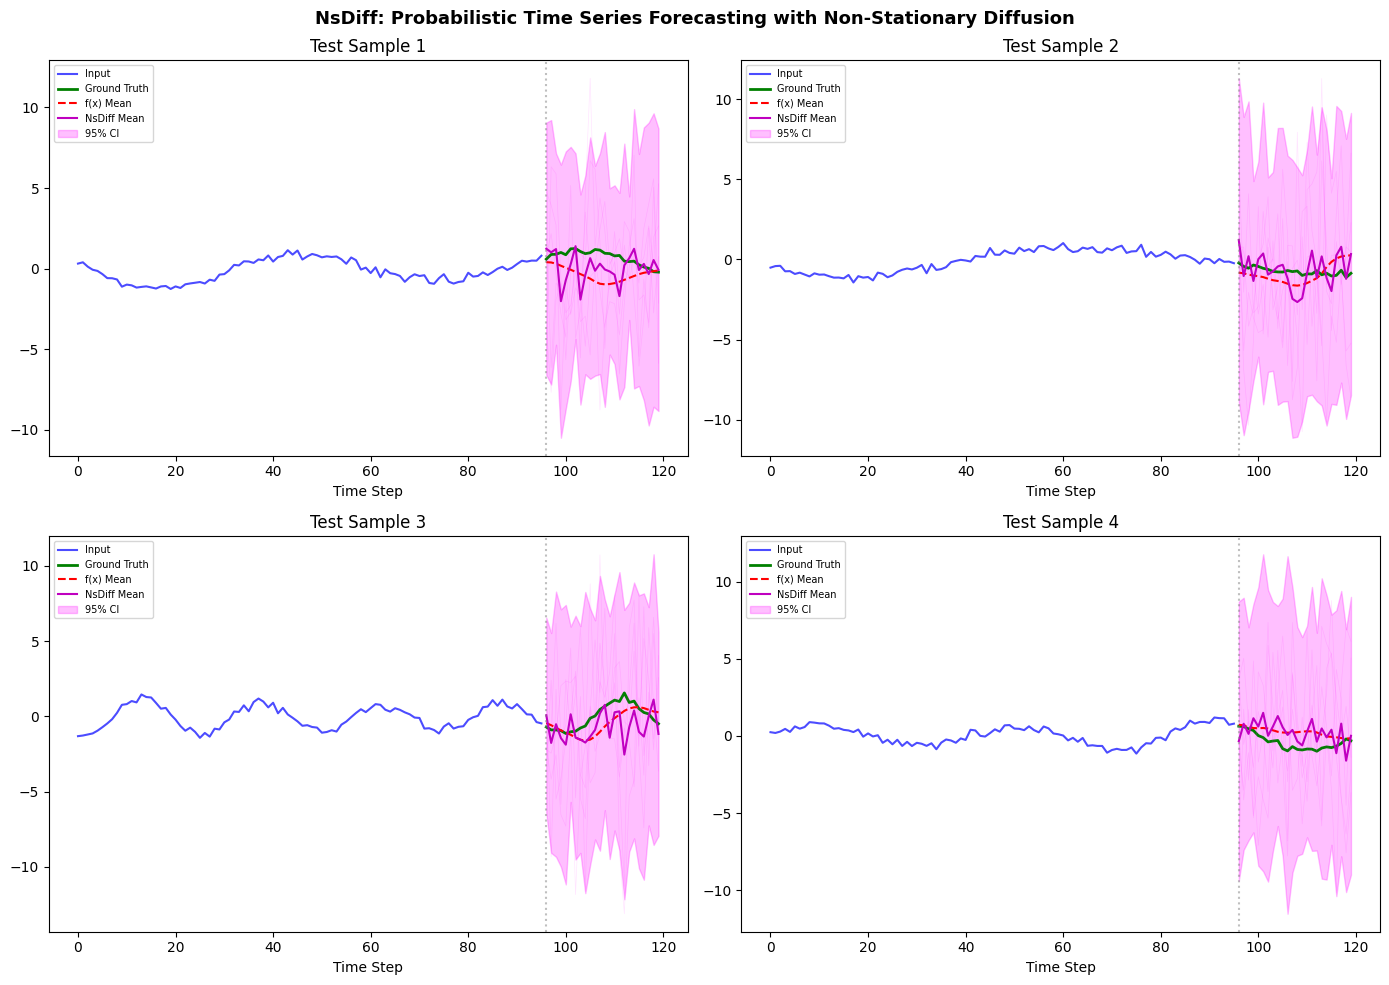

f(x) deterministic MSE: 0.620170
NsDiff diffusion MSE:   5.640720


In [16]:
model.eval()
ema.apply_shadow()

x_enc, x_dec, y_true = next(iter(test_loader))
x_enc_dev = x_enc[:4].to(device)
x_dec_dev = x_dec[:4].to(device)
y_true_plot = y_true[:4]

with torch.no_grad():
    y_0_hat = model.f_model(x_enc_dev, x_dec_dev).cpu()
    samples = model.sample(x_enc_dev, x_dec_dev, n_samples=config.n_samples).cpu()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NsDiff: Probabilistic Time Series Forecasting with Non-Stationary Diffusion',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    feat = 0
    x_plot = x_enc[i, :, feat].numpy()
    y_plot = y_true_plot[i, :, feat].numpy()
    y_hat = y_0_hat[i, :, feat].numpy()

    curves = samples[:, i, :, feat].numpy()
    y_mean = curves.mean(0)
    y_std = curves.std(0)

    t_enc = np.arange(config.seq_len)
    t_pred = np.arange(config.seq_len, config.seq_len + config.pred_len)

    ax.plot(t_enc, x_plot, 'b-', alpha=0.7, label='Input')
    ax.plot(t_pred, y_plot, 'g-', linewidth=2, label='Ground Truth')
    ax.plot(t_pred, y_hat, 'r--', linewidth=1.5, label='f(x) Mean')
    ax.plot(t_pred, y_mean, 'm-', linewidth=1.5, label='NsDiff Mean')
    ax.fill_between(t_pred, y_mean - 2*y_std, y_mean + 2*y_std,
                    alpha=0.25, color='magenta', label='95% CI')
    for s in range(min(5, config.n_samples)):
        ax.plot(t_pred, curves[s], 'magenta', alpha=0.1, linewidth=0.5)
    ax.axvline(x=config.seq_len, color='gray', linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, loc='upper left')
    ax.set_title(f'Test Sample {i+1}')
    ax.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

mse_f = F.mse_loss(y_0_hat, y_true_plot).item()
mse_diff = F.mse_loss(samples.mean(0), y_true_plot).item()
print(f'f(x) deterministic MSE: {mse_f:.6f}')
print(f'NsDiff diffusion MSE:   {mse_diff:.6f}')

## Reverse Diffusion Process Visualization

Visualizes how the sample evolves from pure noise y_T (drawn from the prior N(f(x), g(x))) to a clean prediction y_0 through the non-stationary reverse process.

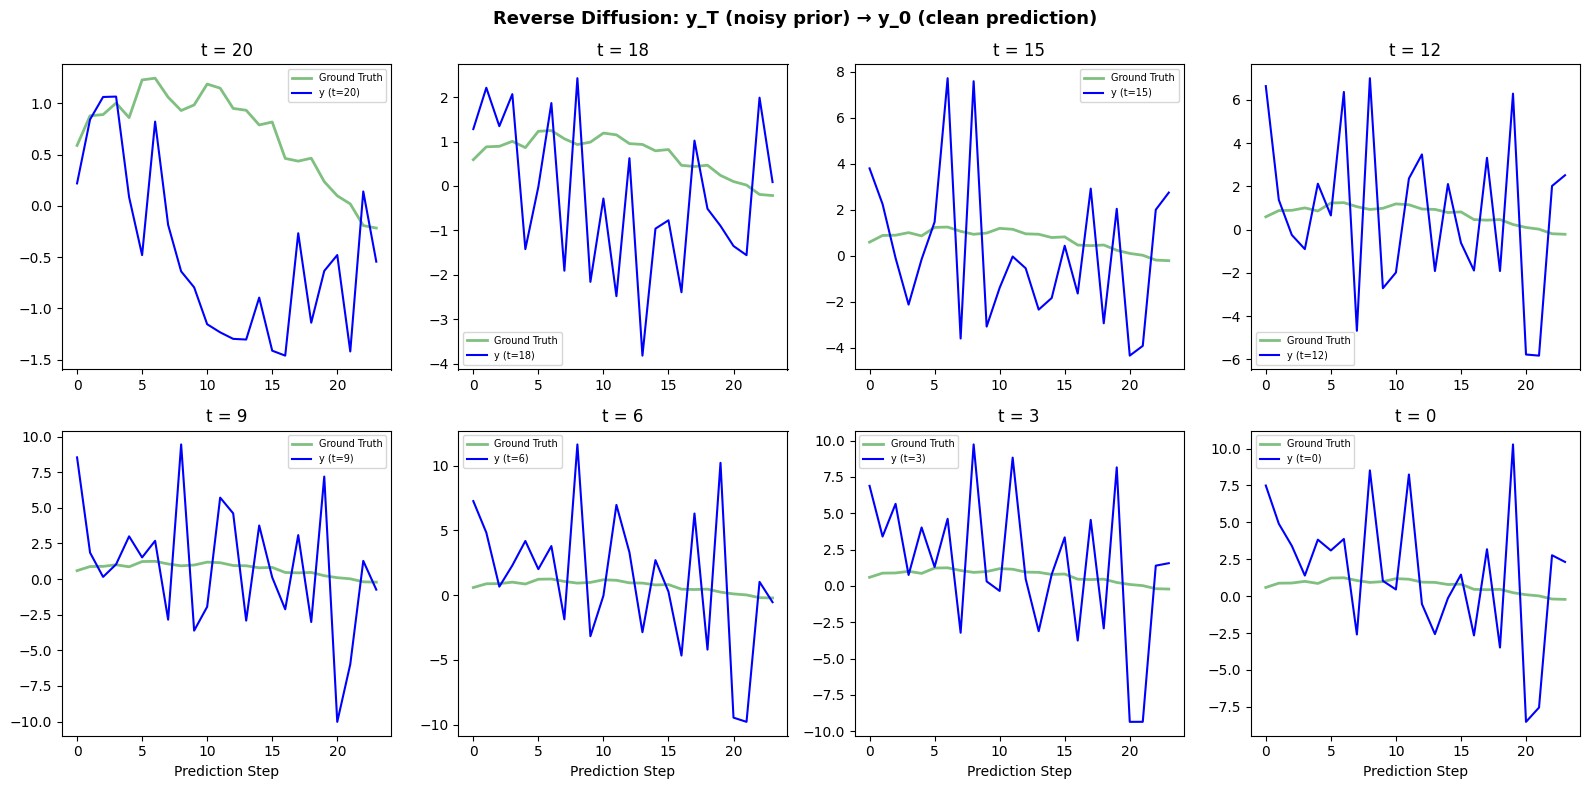

In [17]:
x_enc_single = x_enc[:1].to(device)
x_dec_single = x_dec[:1].to(device)

with torch.no_grad():
    trajectory = model.sample_with_trajectory(x_enc_single, x_dec_single)

feat = 0
n_show = min(8, len(trajectory))
step_indices = np.linspace(0, len(trajectory) - 1, n_show, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Reverse Diffusion: y_T (noisy prior) \u2192 y_0 (clean prediction)',
             fontsize=13, fontweight='bold')

y_gt = y_true[0, :, feat].numpy()
t_pred = np.arange(config.pred_len)

for idx, (ax, step_i) in enumerate(zip(axes.flat, step_indices)):
    y_step = trajectory[step_i][0, :, feat].numpy()
    t_diff = config.timesteps - step_i  # diffusion timestep (T down to 0)

    ax.plot(t_pred, y_gt, 'g-', linewidth=2, alpha=0.5, label='Ground Truth')
    ax.plot(t_pred, y_step, 'b-', linewidth=1.5, label=f'y (t={t_diff})')
    ax.set_title(f't = {t_diff}')
    ax.legend(fontsize=7)
    if idx >= 4:
        ax.set_xlabel('Prediction Step')

plt.tight_layout()
plt.show()

## Adapting for Real Data

To use NsDiff with real station data (e.g., Delhi hourly temperature):

```python
# 1. Load your data as (n_samples, total_len, n_features)
import pandas as pd
df = pd.read_csv('delhi_hourly.csv', parse_dates=['datetime'])
features = ['temperature', 'humidity', 'pressure', 'wind_speed', ...]  # your variables
data = torch.tensor(df[features].values, dtype=torch.float32)  # (T_total, N)

# 2. Create sliding-window samples
class RealDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, label_len):
        self.samples = []
        for i in range(len(data) - seq_len - pred_len + 1):
            x_enc = data[i:i+seq_len]
            y = data[i+seq_len:i+seq_len+pred_len]
            x_dec = torch.cat([data[i+seq_len-label_len:i+seq_len],
                               torch.zeros(pred_len, data.shape[-1])], dim=0)
            self.samples.append((x_enc, x_dec, y))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

# 3. Update config
config.enc_in = len(features)
config.c_out = len(features)  # or subset for target variables
config.seq_len = 168   # e.g., 7 days of hourly data
config.pred_len = 24   # predict next 24 hours
config.label_len = 48
```

The non-stationary diffusion is especially beneficial for climate/weather data where variance changes with diurnal cycles, seasons, and extreme events.